# TabPFN Model Implementation

This notebook implements TabPFN (Tabular Prior-data Fitted Networks) for stock prediction:
1. Uses the same enhanced feature set from notebook 03
2. Implements TabPFN's pre-trained foundation model
3. Compares performance with baseline models
4. Analyzes TabPFN's attention patterns

TabPFN's unique characteristics:
- Pre-trained on millions of synthetic tabular datasets
- No training required (zero-shot learning)
- Two-way 1D attention mechanism
- Built-in prior knowledge about tabular data structure

In [ ]:
%%capture
pip install tabpfn
pip install --quiet statsmodels pmdarima


SyntaxError: invalid syntax (<ipython-input-47-95761a41e67c>, line 1)

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import pytz

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

from tabpfn import TabPFNClassifier

from statsmodels.tsa.statespace.sarimax import SARIMAX

## Data Preparation

We'll reuse the data preparation functions from notebook 03 but adapt them for TabPFN's requirements.

In [ ]:
def fetch_market_data(ticker="^GSPC", start_date='1990-01-01', end_date='2023-12-31'):
    """
    Fetch market data (S&P 500 by default) from Yahoo Finance with UTC timezone.
    """
    data = yf.Ticker(ticker).history(start=start_date, end=end_date)
    data.index = data.index.tz_convert(pytz.UTC)
    return data


def add_enhanced_technical_indicators(df):
    """
    Add multiple technical indicators:
      - Price-based, Moving Averages, Bollinger Bands, etc.
    """
    df['Returns'] = df['Close'].pct_change()
    df['High-Low'] = df['High'] - df['Low']
    df['Open-Close'] = df['Open'] - df['Close']
    df['RSI'] = df['Close'].diff().rolling(window=14).mean() / df['Close'].diff().rolling(window=14).std()

    # Moving Averages and Slopes
    for window in [5, 10, 20, 50, 200]:
        df[f'MA{window}'] = df['Close'].rolling(window=window).mean()
        df[f'MA{window}_Slope'] = df[f'MA{window}'].diff()

    # Volatility indicator
    df['Daily_Volatility'] = df['Returns'].rolling(window=20).std()

    # Bollinger Bands
    rolling_std = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['Close'].rolling(window=20).mean() + (2 * rolling_std)
    df['BB_Lower'] = df['Close'].rolling(window=20).mean() - (2 * rolling_std)
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['Close']

    # Volume-based indicators
    df['Volume_MA5'] = df['Volume'].rolling(window=5).mean()
    df['Volume_MA20'] = df['Volume'].rolling(window=20).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_MA20']

    return df


def add_sarima_features(
    df,
    col_for_sarima='Close',
    order=(1,1,1),
    seasonal_order=(0,0,0,0)
):
    """
    Fit a single SARIMA model in-sample to 'col_for_sarima' (default = 'Close'),
    and then add two new columns:
      1) 'SARIMA_Forecast': the in-sample fitted/predicted values
      2) 'SARIMA_Residual': the difference between actual and predicted
    ---------------------------------------------------------
    NOTE: This is a naive approach that uses the entire time-series
    to train once, then obtains fitted values for the same period.
    For a leak-free approach, do a rolling refit or update.
    """
    # Drop NaNs temporarily to ensure statsmodels won't break on missing data
    df_temp = df.dropna(subset=[col_for_sarima]).copy()

    # Fit SARIMA
    model = SARIMAX(
        df_temp[col_for_sarima],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    # Get in-sample predictions
    # Statsmodels 0-based indexing for predictions: start=0 or start='start_date'
    fitted_values = results.fittedvalues  # length matches df_temp
    residuals = df_temp[col_for_sarima] - fitted_values

    # Merge back into original dataframe
    df['SARIMA_Forecast'] = fitted_values.reindex(df.index)
    df['SARIMA_Residual'] = residuals.reindex(df.index)

    return df


def prepare_features(df):
    """
    - Adds technical indicators
    - Adds SARIMA-based features (fitted vs. residual)
    - Creates 'Target' = next day price difference
    - Creates 'Direction' = 1 if next day up, else 0
    - Drops NA rows
    """
    # Step 1: Basic technicals
    df = add_enhanced_technical_indicators(df)

    # Step 2: SARIMA features (in-sample approach)
    df = add_sarima_features(df, col_for_sarima='Close', order=(1,1,1), seasonal_order=(0,0,0,0))

    # Step 3: Create next-day difference / binary direction
    df['Target'] = df['Close'].shift(-1) - df['Close']
    df['Direction'] = (df['Target'] > 0).astype(int)

    df.dropna(inplace=True)
    return df


def temporal_split(df):
    """
    Train up to '2015-12-31'
    Validation: '2016-01-01' to '2020-12-31'
    Test: '2021-01-01' onwards
    """
    train_end = '2015-12-31'
    val_end   = '2020-12-31'

    train_data = df.loc[df.index <= train_end]
    val_data   = df.loc[(df.index > train_end) & (df.index <= val_end)]
    test_data  = df.loc[df.index > val_end]

    print(f"Train period: {train_data.index.min()} to {train_data.index.max()}")
    print(f"Val period:   {val_data.index.min()} to {val_data.index.max()}")
    print(f"Test period:  {test_data.index.min()} to {test_data.index.max()}")

    return train_data, val_data, test_data



## Modelling

In [ ]:
df = fetch_market_data()  # ^GSPC from 1990 to 2023 by default
df = prepare_features(df)

print("Data shape after feature engineering:", df.shape)
print("Columns:", df.columns.tolist())

train_data, val_data, test_data = temporal_split(df)

# Separate features vs. target
features_to_drop = ['Target', 'Direction']  # We keep the new SARIMA features
X_train = train_data.drop(columns=features_to_drop)
y_train = train_data['Direction']

X_val   = val_data.drop(columns=features_to_drop)
y_val   = val_data['Direction']

X_test  = test_data.drop(columns=features_to_drop)
y_test  = test_data['Direction']

# Check class balance
print("\nClass distribution in training:")
print(y_train.value_counts())

print("\nClass distribution in validation:")
print(y_val.value_counts())

print("\nClass distribution in test:")
print(y_test.value_counts())



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Data shape after feature engineering: (8364, 32)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Returns', 'High-Low', 'Open-Close', 'RSI', 'MA5', 'MA5_Slope', 'MA10', 'MA10_Slope', 'MA20', 'MA20_Slope', 'MA50', 'MA50_Slope', 'MA200', 'MA200_Slope', 'Daily_Volatility', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Volume_MA5', 'Volume_MA20', 'Volume_Ratio', 'SARIMA_Forecast', 'SARIMA_Residual', 'Target', 'Direction']
Train period: 1990-10-16 04:00:00+00:00 to 2015-12-30 05:00:00+00:00
Val period:   2015-12-31 05:00:00+00:00 to 2020-12-30 05:00:00+00:00
Test period:  2020-12-31 05:00:00+00:00 to 2023-12-28 05:00:00+00:00

Class distribution in training:
Direction
1    3386
0    2966
Name: count, dtype: int64

Class distribution in validation:
Direction
1    701
0    558
Name: count, dtype: int64

Class distribution in test:
Direction
1    388
0    365
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("\nShapes:")
print("X_train:", X_train_scaled.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val_scaled.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test_scaled.shape,  "y_test: ", y_test.shape)




Shapes:
X_train: (6352, 30) y_train: (6352,)
X_val:   (1259, 30) y_val:   (1259,)
X_test:  (753, 30) y_test:  (753,)


## TabPFN Model Implementation

In [ ]:
def train_evaluate_tabpfn(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Train a TabPFN model and return predictions on validation & test sets.
    """
    # Initialize model (use device='cuda' if GPU is available)
    model = TabPFNClassifier(device='cuda')
    model.fit(X_train, y_train)

    # Predictions
    val_preds = model.predict(X_val)
    test_preds = model.predict(X_test)

    return model, val_preds, test_preds

model, val_preds, test_preds = train_evaluate_tabpfn(
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    X_test_scaled,  y_test
)



/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr

In [ ]:
print("=== Validation Set Results ===")
print(classification_report(y_val, val_preds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_val, val_preds))

print("\n=== Test Set Results ===")
print(classification_report(y_test, test_preds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_preds))

# Quick check of the prediction distribution
val_pred_counts = pd.Series(val_preds).value_counts()
test_pred_counts = pd.Series(test_preds).value_counts()
print("\nValidation prediction distribution:", val_pred_counts.to_dict())
print("Test prediction distribution:", test_pred_counts.to_dict())

=== Validation Set Results ===
              precision    recall  f1-score   support

           0     0.4819    0.1434    0.2210       558
           1     0.5627    0.8773    0.6856       701

    accuracy                         0.5520      1259
   macro avg     0.5223    0.5103    0.4533      1259
weighted avg     0.5269    0.5520    0.4797      1259

Confusion Matrix:
 [[ 80 478]
 [ 86 615]]

=== Test Set Results ===
              precision    recall  f1-score   support

           0     0.4768    0.3096    0.3754       365
           1     0.5116    0.6804    0.5841       388

    accuracy                         0.5007       753
   macro avg     0.4942    0.4950    0.4797       753
weighted avg     0.4947    0.5007    0.4829       753

Confusion Matrix:
 [[113 252]
 [124 264]]

Validation prediction distribution: {1: 1093, 0: 166}
Test prediction distribution: {1: 516, 0: 237}


In [ ]:
y_train.value_counts()

,count
Direction,
1,3386
0,2966


<Axes: >

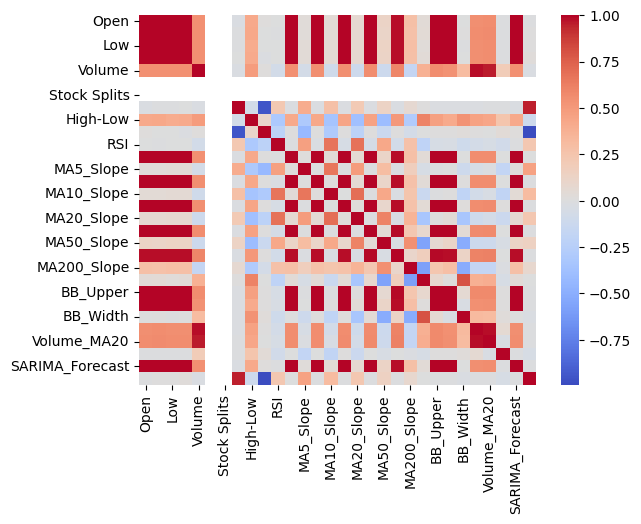

In [ ]:

corr_matrix = pd.DataFrame(X_train_scaled, columns=X_train.columns).corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(feature_importances.sort_values(ascending=False))


MA5_Slope           0.048116
MA10_Slope          0.047198
High-Low            0.046558
Volume_Ratio        0.046155
RSI                 0.044618
MA50_Slope          0.043779
MA20_Slope          0.043479
BB_Width            0.043086
Daily_Volatility    0.042808
Returns             0.042111
SARIMA_Residual     0.041710
MA200_Slope         0.041375
Volume              0.039982
Open-Close          0.039796
Volume_MA5          0.039100
Volume_MA20         0.036031
MA200               0.029871
BB_Lower            0.027776
MA50                0.027653
BB_Upper            0.027122
Close               0.027052
High                0.025529
SARIMA_Forecast     0.025514
MA10                0.025189
Low                 0.024851
MA5                 0.024822
Open                0.024485
MA20                0.024235
Stock Splits        0.000000
Dividends           0.000000
dtype: float64


In [ ]:
y_pred = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.93      0.64       365
           1       0.53      0.07      0.13       388

    accuracy                           0.49       753
   macro avg       0.51      0.50      0.38       753
weighted avg       0.51      0.49      0.37       753



In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_scaled, y_train)
xgb_test_preds = xgb.predict(X_test_scaled)
print(classification_report(y_test, xgb_test_preds))


              precision    recall  f1-score   support

           0       0.48      0.92      0.64       365
           1       0.52      0.08      0.14       388

    accuracy                           0.49       753
   macro avg       0.50      0.50      0.39       753
weighted avg       0.50      0.49      0.38       753



## Analysis and Visualization

In [ ]:
def analyze_predictions(y_true, predictions, probabilities, title):
    """Analyze and visualize model predictions"""
    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_true, predictions),
                annot=True, fmt='d',
                xticklabels=['Down', 'No Change', 'Up'],
                yticklabels=['Down', 'No Change', 'Up'])
    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Prediction Confidence Distribution
    plt.figure(figsize=(10, 6))
    max_probs = np.max(probabilities, axis=1)
    plt.hist(max_probs, bins=50)
    plt.title(f'{title} - Prediction Confidence Distribution')
    plt.xlabel('Maximum Probability')
    plt.ylabel('Count')
    plt.show()

    # Accuracy vs Confidence
    conf_levels = np.linspace(0.3, 1.0, 20)
    accuracies = []
    counts = []

    for conf in conf_levels:
        mask = max_probs >= conf
        if np.sum(mask) > 0:
            acc = np.mean(predictions[mask] == y_true[mask])
            accuracies.append(acc)
            counts.append(np.sum(mask))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(conf_levels[:len(accuracies)], accuracies)
    plt.title('Accuracy vs Confidence Threshold')
    plt.xlabel('Confidence Threshold')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(conf_levels[:len(counts)], counts)
    plt.title('Number of Predictions vs Confidence Threshold')
    plt.xlabel('Confidence Threshold')
    plt.ylabel('Number of Predictions')
    plt.tight_layout()
    plt.show()

# Analyze validation results
print("Analyzing Validation Set Results:")
analyze_predictions(y_val, results['val_predictions'],
                   results['val_probabilities'], 'Validation Set')

# Analyze test results
print("\nAnalyzing Test Set Results:")
analyze_predictions(y_test, results['test_predictions'],
                   results['test_probabilities'], 'Test Set')

In [ ]:
stop

## Trading Strategy Implementation

In [ ]:
def implement_trading_strategy(predictions, probabilities, prices, confidence_threshold=0.8):
    """Implement a trading strategy based on TabPFN predictions"""
    max_probs = np.max(probabilities, axis=1)
    positions = np.zeros_like(predictions)

    # Only take positions when confidence is high
    confident_mask = max_probs >= confidence_threshold
    positions[confident_mask] = predictions[confident_mask]

    # Calculate returns
    price_returns = np.diff(prices) / prices[:-1]
    strategy_returns = positions[:-1] * price_returns

    # Calculate metrics
    total_return = np.prod(1 + strategy_returns) - 1
    annual_return = (1 + total_return) ** (252 / len(strategy_returns)) - 1
    sharpe_ratio = np.sqrt(252) * np.mean(strategy_returns) / np.std(strategy_returns)
    max_drawdown = np.min(np.cumprod(1 + strategy_returns)) - 1

    return {
        'positions': positions,
        'returns': strategy_returns,
        'total_return': total_return,
        'annual_return': annual_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown
    }

# Implement strategy on test set
test_prices = test_data['Close'].values[20:]  # Adjust for lookback window
strategy_results = implement_trading_strategy(
    results['test_predictions'],
    results['test_probabilities'],
    test_prices
)

# Print strategy results
print("Trading Strategy Results:")
print(f"Total Return: {strategy_results['total_return']:.2%}")
print(f"Annual Return: {strategy_results['annual_return']:.2%}")
print(f"Sharpe Ratio: {strategy_results['sharpe_ratio']:.2f}")
print(f"Maximum Drawdown: {strategy_results['max_drawdown']:.2%}")

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(np.cumprod(1 + strategy_results['returns']) - 1)
plt.title('Cumulative Strategy Returns')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()